# Combinaison de DL et de ML

>Ici nous allons entraîner un CNN afin d'extraire les features des images.
>
>Sauf que au lieu de donner les features extraites (i.e. après le flatten) aux couches denses, nous allons les utiliser pour entraîner un arbre de décision.
>Dans la pratique, il faudrait évidemment utiliser des algorithmes plus développés (*e.g.* XGBoost, CatBoost, LGBM, *etc.*) et partir d'un modèle déjà entraîné afin d'extraire les features (nous y reviendrons plus tard).
>
>Ce procédé a déjà fait ses preuves dans certaines conditions (*e.g.* beaucoup de classes > 500 et avec peu d'observations). Ici, dans notre cas ce n'est pas nécessaire. Il ne s'agit que d'une illustration à titre pédagogique.
>
>Cette façon de procéder a deux gros avantages par rapport à d'autres techniques de réduction de dimensionnalité telles que la PCA ou LDA:
>- il s'agit d'un apprentissage supervisé
>- il s'agit d'une technique non linéaire

In [22]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.datasets import mnist

from keras.layers import Dense, Flatten, Convolution2D, MaxPooling2D, Reshape, Rescaling

from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.pipeline import make_pipeline

In [6]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [7]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


In [8]:
def get_cnn(n_class, activation: str = 'relu') -> keras.Sequential:
    model = keras.Sequential([
        # Convolution layers need 3 dimensions for the images.
        # The third dimensions is for the color channels
        Reshape((28, 28, 1)),
        Rescaling(1./255),

        Convolution2D(filters=16, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Convolution2D(filters=32, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Convolution2D(filters=64, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Flatten(),

        Dense(50, activation=activation),
        Dense(50, activation=activation),

        Dense(n_class, activation='softmax')

    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


In [10]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [12]:
cnn = get_cnn(10)
cnn.fit(X_train, y_train, epochs=20, batch_size=1024)

Epoch 1/20
59/59 [==============================] - 1s 6ms/step - loss: 1.6183 - accuracy: 0.4805
Epoch 2/20
59/59 [==============================] - 0s 5ms/step - loss: 0.4675 - accuracy: 0.8630
Epoch 3/20
59/59 [==============================] - 0s 5ms/step - loss: 0.2513 - accuracy: 0.9258
Epoch 4/20
59/59 [==============================] - 0s 5ms/step - loss: 0.1878 - accuracy: 0.9432
Epoch 5/20
59/59 [==============================] - 0s 5ms/step - loss: 0.1571 - accuracy: 0.9518
Epoch 6/20
59/59 [==============================] - 0s 5ms/step - loss: 0.1353 - accuracy: 0.9588
Epoch 7/20
59/59 [==============================] - 0s 5ms/step - loss: 0.1188 - accuracy: 0.9638
Epoch 8/20
59/59 [==============================] - 0s 5ms/step - loss: 0.1078 - accuracy: 0.9671
Epoch 9/20
59/59 [==============================] - 0s 5ms/step - loss: 0.0994 - accuracy: 0.9690
Epoch 10/20
59/59 [==============================] - 0s 5ms/step - loss: 0.0910 - accuracy: 0.9722
Epoch 11/20
59/59 [

In [13]:
cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 rescaling_1 (Rescaling)     (None, 28, 28, 1)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 27, 27, 16)        80        
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 13, 13, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 12, 12, 32)        2080      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 6, 6, 32)         0         
 2D)                                                  

In [14]:
for i, layer in enumerate(cnn.layers):
    print(i, layer.name)

0 reshape_1
1 rescaling_1
2 conv2d_3
3 max_pooling2d_3
4 conv2d_4
5 max_pooling2d_4
6 conv2d_5
7 max_pooling2d_5
8 flatten_1
9 dense_3
10 dense_4
11 dense_5


# Redéfinir les sorties

Ici, nous rédéfinissons les sorties de notre modèle afin que le *predict* ne renvoie plus les valeurs de sorties de la dernière couche mais ici de la 9eme

In [15]:
extractor = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[8].output)

X_train = extractor.predict(X_train)
X_test = extractor.predict(X_test)

In [19]:
X_train.shape

(60000, 256)

In [20]:
dt = DecisionTreeClassifier(random_state=1)
params = {'max_depth': np.arange(10, 31, 5)}

grid = GridSearchCV(dt, params, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=1), n_jobs=-1,
             param_grid={'max_depth': array([10, 15, 20, 25, 30])},
             scoring='accuracy')

In [23]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,13.082630,0.507488,0.005400,0.000490,10,{'max_depth': 10},0.877500,0.875333,0.879500,0.874167,0.882583,0.877817,0.003005,5
1,17.813801,0.412826,0.005756,0.000888,15,{'max_depth': 15},0.902750,0.899917,0.898667,0.897417,0.907000,0.901150,0.003418,1
2,21.015670,0.187097,0.005199,0.000747,20,{'max_depth': 20},0.903833,0.898833,0.897167,0.897333,0.905417,0.900517,0.003441,2
3,23.526000,0.365237,0.006447,0.001400,25,{'max_depth': 25},0.900250,0.899833,0.894917,0.897167,0.906333,0.899700,0.003837,3
4,24.299163,2.138702,0.004700,0.001186,30,{'max_depth': 30},0.899833,0.898833,0.896583,0.894167,0.904333,0.898750,0.003408,4


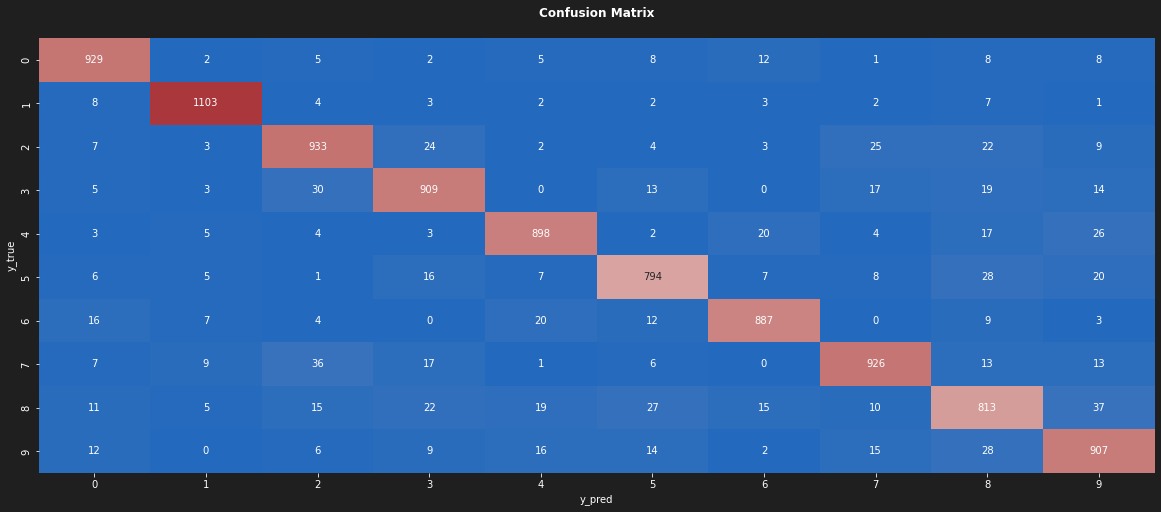

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       980
           1       0.97      0.97      0.97      1135
           2       0.90      0.90      0.90      1032
           3       0.90      0.90      0.90      1010
           4       0.93      0.91      0.92       982
           5       0.90      0.89      0.90       892
           6       0.93      0.93      0.93       958
           7       0.92      0.90      0.91      1028
           8       0.84      0.83      0.84       974
           9       0.87      0.90      0.89      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [24]:
dt = grid.best_estimator_

y_pred = dt.predict(X_test)

plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))